In [ ]:
'''
IGNORE
import os
from pathlib import Path


# --- FIND GIT REPOSITORY ROOT ---
def find_repo_root():
    path = Path.cwd().resolve()
    
    for parent in [path] + list(path.parents):
        if (parent / ".git").exists():
            return parent
    
    raise RuntimeError("Git repository root not found")


REPO_ROOT = find_repo_root()
print(f"Repository root found at: {REPO_ROOT}")

# Optional: list files in repo root
print(os.listdir(REPO_ROOT))
'''

Repository root found at: /Users/f.kissi/Library/CloudStorage/OneDrive-LoughboroughUniversity/robotics
['labs', 'best_model_og.pth', '.DS_Store', 'debug.txt', 'motors.py', 'robotics_cw copy.ipynb', 'dataset', 'pixel.png', 'label_check2.png', '__pycache__', 'resnet18-f37072fd.pth', 'line_fit_grid.png', 'robotics_http.txt', '.gitignore', '.venv', 'train_resnet.ipynb', '.git', 'robot_utils.py', 'colour_files', 'image.png', 'robotics_cw.ipynb']


In [2]:
import sys
sys.path.append(str(REPO_ROOT))

from robot_utils import (
    extract_from_frames,
    read_image_files
)

In [ ]:
from sklearn.model_selection import train_test_split
import shutil

'''
Used to process raw AVI files into a structured dataset of images for training a ResNet model.

LABEL_NAMES = ["left", "straight", "right"]
raw_dir   = REPO_ROOT / "dataset/raw"
split_dir = REPO_ROOT / "dataset/split"


# Clear old dataset
#if raw_dir.exists():
    #shutil.rmtree(raw_dir)

if split_dir.exists():
    shutil.rmtree(split_dir)


colour_dir   = REPO_ROOT / "colour_files"
colour_files = sorted(colour_dir.glob("*.avi"))

print(f"Found {len(colour_files)} AVI files:")
for f in colour_files:
    print(f"  {f.name}")

# Extract
all_records = []
for colour_file in colour_files:
    colour_path   = colour_dir / colour_file
    colour_frames = read_image_files(str(colour_path))
    print(f"Processing {colour_file}: {len(colour_frames)} frames")

    records = extract_from_frames(
        colour_frames,
        str(raw_dir),
        LABEL_NAMES,
        frame_skip=3,
        min_pixels=1000
    )
    all_records.extend(records)

# Class distribution
print("\nClass distribution:")
for name in LABEL_NAMES:
    count = len(list((raw_dir / name).glob("*.jpg")))
    print(f"  {name}: {count}")

# Split
for name in LABEL_NAMES:
    files = list((raw_dir / name).glob("*.jpg"))
    train_f, val_f = train_test_split(
        files, test_size=0.2, random_state=42
    )
    for split, split_files in [("train", train_f), ("val", val_f)]:
        dest = split_dir / split / name
        dest.mkdir(parents=True, exist_ok=True)
        for f in split_files:
            shutil.copy(f, dest / f.name)

# Sanity check
print("\nSplit distribution:")
for split in ["train", "val"]:
    for name in LABEL_NAMES:
        n = len(list((split_dir / split / name).glob("*.jpg")))
        print(f"  {split}/{name}: {n}")

'''


Split distribution:
  train/left: 1316
  train/straight: 2936
  train/right: 1608
  val/left: 330
  val/straight: 734
  val/right: 403


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, transforms, datasets
from pathlib import Path
import matplotlib.pyplot as plt

# --- Config ---
DATA_DIR   = Path("dataset/split")
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
DEVICE     = torch.device("mps" if torch.backends.mps.is_available() 
                          else "cuda" if torch.cuda.is_available() 
                          else "cpu")
print(f"Using device: {DEVICE}")

# --- Transforms ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- Datasets ---

train_dataset = datasets.ImageFolder(DATA_DIR / "train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(DATA_DIR / "val",   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

# --- Model ---
class LaneClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.load_state_dict(torch.load(
            #REPO_ROOT / 
            "resnet18-f37072fd.pth",
            map_location="cpu"
        ))
        
        for param in backbone.parameters():
            param.requires_grad = False
            
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

Using device: mps
Train: 5860 | Val: 1467
Classes: ['left', 'right', 'straight']


In [ ]:
model = LaneClassifier(num_classes=3).to(DEVICE)

# --- Weighted loss ---
#left=0, right=1, straight=2 
counts  = torch.tensor([1646, 2011, 3670], dtype=torch.float)
weights = (1.0 / counts)
weights = weights / weights.sum() * 3
criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))

# Only train the new head
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [3]:
# --- Training loop ---
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total * 100

In [7]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.3f} acc: {train_acc:.1f}% | "
          f"Val loss: {val_loss:.3f} acc: {val_acc:.1f}%"
          + (" <- best" if val_acc == best_val_acc else ""))

print(f"\nBest val accuracy: {best_val_acc:.1f}%")

Epoch 01/20 | Train loss: 0.778 acc: 53.3% | Val loss: 0.814 acc: 62.1% <- best
Epoch 02/20 | Train loss: 0.656 acc: 62.6% | Val loss: 0.767 acc: 65.6% <- best
Epoch 03/20 | Train loss: 0.604 acc: 67.2% | Val loss: 0.652 acc: 75.5% <- best
Epoch 04/20 | Train loss: 0.569 acc: 70.1% | Val loss: 0.673 acc: 71.8%
Epoch 05/20 | Train loss: 0.548 acc: 70.9% | Val loss: 0.617 acc: 75.1%
Epoch 06/20 | Train loss: 0.555 acc: 70.1% | Val loss: 0.638 acc: 74.0%
Epoch 07/20 | Train loss: 0.526 acc: 71.6% | Val loss: 0.572 acc: 76.8% <- best
Epoch 08/20 | Train loss: 0.511 acc: 72.9% | Val loss: 0.595 acc: 75.7%
Epoch 09/20 | Train loss: 0.476 acc: 74.9% | Val loss: 0.584 acc: 76.5%
Epoch 10/20 | Train loss: 0.478 acc: 74.7% | Val loss: 0.636 acc: 74.9%
Epoch 11/20 | Train loss: 0.480 acc: 74.9% | Val loss: 0.582 acc: 76.9% <- best
Epoch 12/20 | Train loss: 0.472 acc: 75.5% | Val loss: 0.587 acc: 76.7%
Epoch 13/20 | Train loss: 0.468 acc: 75.7% | Val loss: 0.560 acc: 78.4% <- best
Epoch 14/20 | Tr

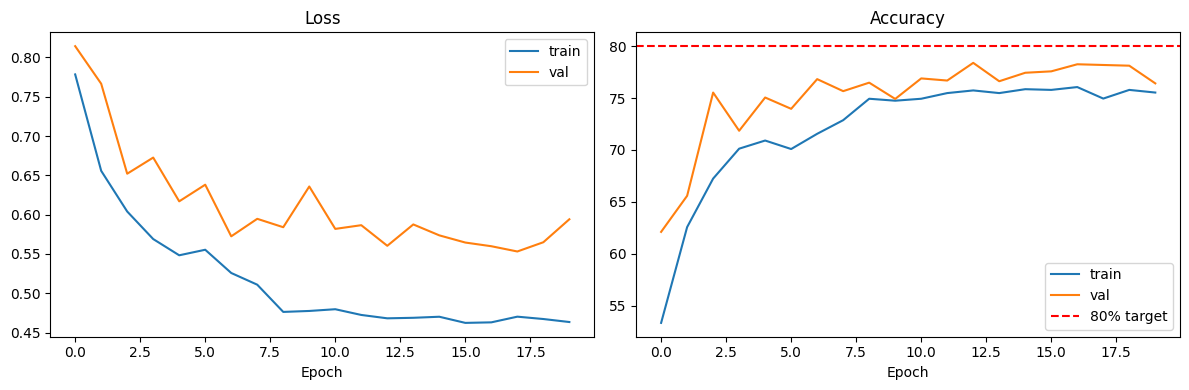

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"],   label="val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"],   label="val")
ax2.axhline(80, color="red", linestyle="--", label="80% target")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [9]:
best_val_acc = 78.4

# Unfreeze layer4
for param in model.model.layer4.parameters():
    param.requires_grad = True

# Much lower LR to avoid destroying pretrained weights
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Load best weights before fine-tuning
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE,weights_only=True))

# Run another 15 epochs
EPOCHS = 15
history2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)
    history2["train_acc"].append(train_acc)
    history2["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.3f} acc: {train_acc:.1f}% | "
          f"Val loss: {val_loss:.3f} acc: {val_acc:.1f}%"
          + (" <- best" if val_acc == best_val_acc else ""))

print(f"\nBest val accuracy: {best_val_acc:.1f}%")

Epoch 01/15 | Train loss: 0.311 acc: 85.1% | Val loss: 0.311 acc: 88.0% <- best
Epoch 02/15 | Train loss: 0.184 acc: 91.2% | Val loss: 0.174 acc: 93.4% <- best
Epoch 03/15 | Train loss: 0.140 acc: 93.9% | Val loss: 0.179 acc: 93.7% <- best
Epoch 04/15 | Train loss: 0.132 acc: 94.4% | Val loss: 0.166 acc: 94.1% <- best
Epoch 05/15 | Train loss: 0.120 acc: 94.9% | Val loss: 0.122 acc: 95.7% <- best
Epoch 06/15 | Train loss: 0.086 acc: 96.3% | Val loss: 0.100 acc: 96.5% <- best
Epoch 07/15 | Train loss: 0.079 acc: 96.5% | Val loss: 0.110 acc: 96.5% <- best
Epoch 08/15 | Train loss: 0.069 acc: 97.2% | Val loss: 0.117 acc: 96.0%
Epoch 09/15 | Train loss: 0.072 acc: 97.1% | Val loss: 0.083 acc: 96.9% <- best
Epoch 10/15 | Train loss: 0.067 acc: 96.8% | Val loss: 0.084 acc: 97.1% <- best
Epoch 11/15 | Train loss: 0.066 acc: 96.9% | Val loss: 0.093 acc: 96.9%
Epoch 12/15 | Train loss: 0.066 acc: 97.0% | Val loss: 0.083 acc: 96.9%
Epoch 13/15 | Train loss: 0.066 acc: 97.3% | Val loss: 0.077 acc

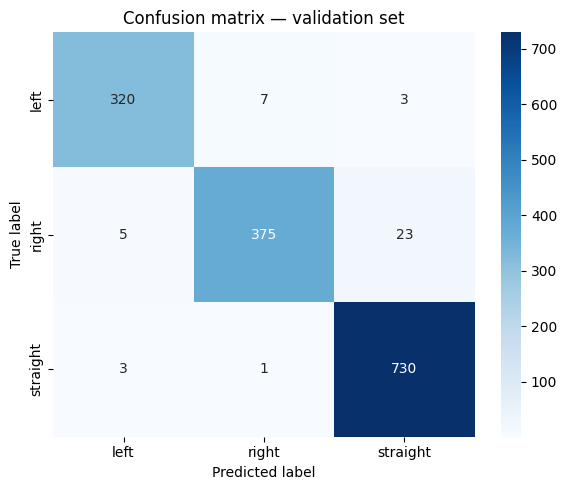

              precision    recall  f1-score   support

        left       0.98      0.97      0.97       330
       right       0.98      0.93      0.95       403
    straight       0.97      0.99      0.98       734

    accuracy                           0.97      1467
   macro avg       0.97      0.96      0.97      1467
weighted avg       0.97      0.97      0.97      1467



In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Load best weights
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = val_dataset.classes  # ['left', 'right', 'straight']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion matrix — validation set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Per-class breakdown
print(classification_report(all_labels, all_preds, target_names=class_names))